<a href="https://colab.research.google.com/github/Samu24042/CienciaDeDatos/blob/main/ExamenPractico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [212]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import shapiro
from scipy import stats

In [213]:
df_consumo = pd.read_csv('consumo_energetico.csv')
df_consumo.head()

,area_vivienda_m2,habitantes,temperatura_promedio,electrodomesticos,horas_aire_acondicionado,antiguedad_vivienda,horas_iluminacion,consumo_mensual_kwh,consumo_historico_kwh,codigo_sensor
0,109.207037,1,25.800171,18.0,7.330210,15,3.999229,1028.78,NaN,234374
1,85.178151,4,24.324206,19.0,9.807910,27,4.505261,1130.61,NaN,541493
2,127.789267,4,26.815253,17.0,9.169392,13,10.903745,1205.23,NaN,242927
3,119.669128,6,23.975762,19.0,8.378231,12,9.474599,1311.03,NaN,847509
4,156.242693,6,23.279238,12.0,3.523274,28,6.808261,1163.97,NaN,181765


In [214]:
# --- INSPECCIÓN DE NULOS Y ELIMINACIÓN DE COLUMNAS ---

# isna().sum() nos muestra cuántos valores faltantes hay por cada columna
print("--- Valores nulos por columna ---")
print(df_consumo.isna().sum())

--- Valores nulos por columna ---
area_vivienda_m2              0
habitantes                    0
temperatura_promedio          0
electrodomesticos            10
horas_aire_acondicionado      0
antiguedad_vivienda           0
horas_iluminacion             0
consumo_mensual_kwh           0
consumo_historico_kwh       286
codigo_sensor                 0
dtype: int64


In [215]:
# Eliminar columna de consumo_historico_kwh :
df_consumo.drop("consumo_historico_kwh", axis=1, inplace=True)

# Eliminar filas con valores vacios de electrodomesticos :
df_consumo.dropna(subset=['electrodomesticos'], inplace=True)

print("--- Valores nulos por columna ---")
print(df_consumo.isna().sum())

--- Valores nulos por columna ---
area_vivienda_m2            0
habitantes                  0
temperatura_promedio        0
electrodomesticos           0
horas_aire_acondicionado    0
antiguedad_vivienda         0
horas_iluminacion           0
consumo_mensual_kwh         0
codigo_sensor               0
dtype: int64


In [216]:
# Cuenta las veces que aparece cada valor y filtra los que son mayores a 1
conteos = df_consumo['codigo_sensor'].value_counts()
valores_repetidos = conteos[conteos > 1].index.tolist()

print(valores_repetidos)

[792603]


In [217]:
# Modifica el DataFrame original eliminando cualquier fila con valor repetido
df_consumo.drop_duplicates(subset=['codigo_sensor'], keep=False, inplace=True)

# Cuenta las veces que aparece cada valor y filtra los que son mayores a 1
conteos = df_consumo['codigo_sensor'].value_counts()
valores_repetidos = conteos[conteos > 1].index.tolist()

print(valores_repetidos)

[]


In [218]:
# Modifica el DataFrame original eliminando las filas con valores negativos
df_consumo.drop(df_consumo[df_consumo['area_vivienda_m2'] < 0].index, inplace=True)
df_consumo.drop(df_consumo[df_consumo['habitantes'] < 0].index, inplace=True)
df_consumo.drop(df_consumo[df_consumo['consumo_mensual_kwh'] < 0].index, inplace=True)

In [219]:
display(df.head())

,area_vivienda_m2,habitantes,temperatura_promedio,electrodomesticos,horas_aire_acondicionado,antiguedad_vivienda,horas_iluminacion,consumo_mensual_kwh,consumo_historico_kwh,codigo_sensor
0,109.207037,1,25.800171,18.0,7.330210,15,3.999229,1028.78,NaN,234374
1,85.178151,4,24.324206,19.0,9.807910,27,4.505261,1130.61,NaN,541493
2,127.789267,4,26.815253,17.0,9.169392,13,10.903745,1205.23,NaN,242927
3,119.669128,6,23.975762,19.0,8.378231,12,9.474599,1311.03,NaN,847509
4,156.242693,6,23.279238,12.0,3.523274,28,6.808261,1163.97,NaN,181765


In [220]:
X = df_consumo[['area_vivienda_m2', 'habitantes', 'temperatura_promedio','electrodomesticos','horas_aire_acondicionado','antiguedad_vivienda', 'horas_iluminacion']]
y = df_consumo['consumo_mensual_kwh']

# Instanciamos el modelo y ajustamos modelo
modelo_ml = LinearRegression()
modelo_ml.fit(X, y)

print("Intercepto (Beta_0):", modelo_ml.intercept_)
print("Variables:", X.columns)
print("Coeficientes (Betas):", modelo_ml.coef_)

Intercepto (Beta_0): 23.398061183107302
Variables: Index(['area_vivienda_m2', 'habitantes', 'temperatura_promedio',
       'electrodomesticos', 'horas_aire_acondicionado', 'antiguedad_vivienda',
       'horas_iluminacion'],
      dtype='object')
Coeficientes (Betas): [ 3.38206828 39.21384784 -0.12395746 25.42242579 17.74412819 -0.13006443
 -0.62752977]


In [221]:
# Calculamos las métricas de error y precisión
predicciones = modelo_ml.predict(X)
mse = mean_squared_error(y, predicciones)
r2 = r2_score(y, predicciones)

print(f"\nError Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")


Error Cuadrático Medio (MSE): 573.12
Coeficiente de Determinación (R^2): 0.9793


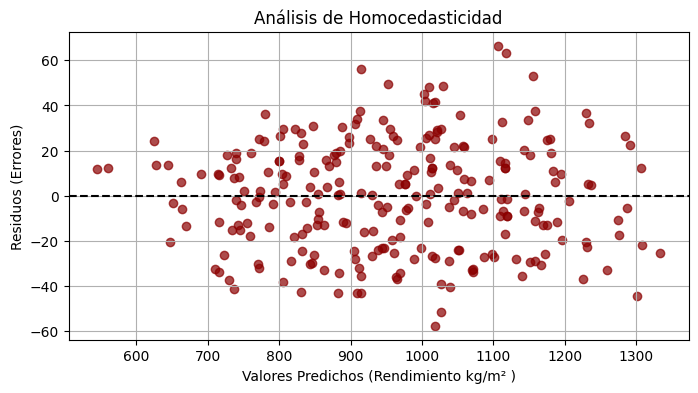

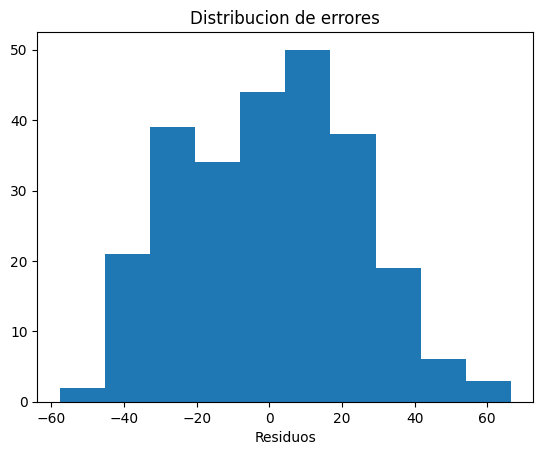

Estadístico: 5.88729330870366
p-value: 0.05267329677825441
Los datos parecen seguir una distribución normal


In [222]:
# --- EVALUACIÓN DE RESIDUOS ---

# El residuo es la diferencia entre el valor real y el valor predicho
residuos = y - predicciones

# Gráfica de Residuos vs Predicciones
plt.figure(figsize=(8, 4))
plt.scatter(predicciones, residuos, alpha=0.7, color="darkred")
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análisis de Homocedasticidad')
plt.xlabel('Valores Predichos (Rendimiento kg/m² )')
plt.ylabel('Residuos (Errores)')
plt.grid(True)
plt.show()

plt.hist(residuos)
plt.title('Distribucion de errores')
plt.xlabel('Residuos')
plt.show()

# ---  PROPONER AQUÍ UN CÓDIGO PARA EVALUAR SI LOS ERRORES SE DISTRIBUYEN DE FORMA NORMAL"
from scipy import stats
stat, p = stats.normaltest(residuos)

print("Estadístico:", stat)
print("p-value:", p)
if p > 0.05:
    print("Los datos parecen seguir una distribución normal")
else:
    print("Los datos NO siguen una distribución normal")

In [224]:
# Estimación con el modelo de regresión lineal :

# Crear un DataFrame con los valores específicos que quieres evaluar
nuevos_datos = pd.DataFrame([{
    'area_vivienda_m2': 109,
    'habitantes': 1,
    'temperatura_promedio': 26,
    'electrodomesticos': 18,
    'horas_aire_acondicionado': 7,
    'antiguedad_vivienda': 15,
    'horas_iluminacion': 4
}])

# Añadir la constante para que coincida con la estructura del modelo
# statsmodels añadirá una columna llamada 'const' con el valor 1.0 al inicio
prediccion = modelo_ml.predict(nuevos_datos)

print("El consumo mensual estimado es:", prediccion[0], "kWh")

El consumo mensual estimado es: 1005.3859339990054 kWh
